# Visualização de Métricas – Contrastive TRBA

Este notebook reproduz os mesmos gráficos gerados por `visualize/plot_metrics.py`.

**Instruções:**
1. Na célula abaixo, ajuste o caminho de `METRICS_JSON` se necessário.
2. Execute todas as células sequencialmente para gerar as figuras.

In [1]:
# ── Célula 1: Importações e Carregamento de Dados ────────────────────────────

import json
import re
from pathlib import Path
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as PathEffects
import numpy as np

# SciencePlots styles
import scienceplots  # noqa: F401 – register styles

%matplotlib inline

# ── Caminho do arquivo de métricas (ajuste aqui) ──────────────────────────────
METRICS_JSON = Path("../results/rodo_ufpr/metrics.json")
DATASET_NAME = METRICS_JSON.parent.name  # ex: "rodo_ufpr"

# ── Constantes ────────────────────────────────────────────────────────────────

MODEL_NAME_MAP = [
    (re.compile(r"^BASE\+1D\+TPS$", re.I), "TRBA"),
    (re.compile(r"^CTR\+1D\+TPS$", re.I), "CTRBA"),
    (re.compile(r"^BASE\+2D\+TPS$", re.I), "TRB2A"),
    (re.compile(r"^CTR\+2D\+TPS$", re.I), "CTRB2A"),
    (re.compile(r"^BASE\b.*\bTPS\b.*\b1D\b", re.I), "TRBA"),
    (re.compile(r"^BASE\b.*\b1D\b.*\bTPS\b", re.I), "TRBA"),
    (re.compile(r"^CTR\b.*\bTPS\b.*\b1D\b", re.I), "CTRBA"),
    (re.compile(r"^CTR\b.*\b1D\b.*\bTPS\b", re.I), "CTRBA"),
    (re.compile(r"^BASE\b.*\bTPS\b.*\b2D\b", re.I), "TRB2A"),
    (re.compile(r"^BASE\b.*\b2D\b.*\bTPS\b", re.I), "TRB2A"),
    (re.compile(r"^CTR\b.*\bTPS\b.*\b2D\b", re.I), "CTRB2A"),
    (re.compile(r"^CTR\b.*\b2D\b.*\bTPS\b", re.I), "CTRB2A"),
]

ALLOWED_MODELS = {"TRBA", "CTRBA", "TRB2A", "CTRB2A"}
MODEL_ORDER = ["CTRB2A", "CTRBA", "TRB2A", "TRBA"]

MODEL_COLORS = {
    "CTRB2A": "#3B82F6",  # Blue
    "CTRBA": "#8B5CF6",   # Violet
    "TRB2A": "#F97316",   # Orange
    "TRBA": "#6B7280",    # Gray (baseline)
}

# ── Helpers ───────────────────────────────────────────────────────────────────

def normalize_label(label: str) -> str:
    if not label:
        return label
    if label in ALLOWED_MODELS:
        return label
    for pattern, canonical in MODEL_NAME_MAP:
        if pattern.search(label.strip()):
            return canonical
    return label


def load_metrics(json_path: Path) -> dict[str, Any]:
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)
    for m in data.get("models", []):
        m["label"] = normalize_label(m["label"])
    data["models"] = [m for m in data["models"] if m["label"] in ALLOWED_MODELS]
    data["models"].sort(key=lambda m: m["plate_accuracy"], reverse=True)
    return data


def ordered_models(models: list[dict]) -> list[dict]:
    label_to_model = {m["label"]: m for m in models}
    return [label_to_model[lbl] for lbl in MODEL_ORDER if lbl in label_to_model]


def _annotate_bar(
    ax, bar, value: float, ref_value,
    higher_is_better: bool = True,
    value_fmt: str = "{:.2f}%",
    delta_fmt: str = "{:+.2f} p.p.",
    fontsize_value: int = 7,
    fontsize_delta: int = 5,
):
    cx = bar.get_x() + bar.get_width() / 2
    top = bar.get_height()

    if top > 50:
        outset = 0.25
        inset = 0.25
    else:
        outset = 0.02
        inset = 0.02

    ax.text(
        cx, top + outset,
        value_fmt.format(value),
        ha="center", va="bottom",
        fontsize=fontsize_value, fontweight="bold",
        color="black",
    )

    if ref_value is None:
        return
    delta = value - ref_value
    if abs(delta) < 1e-9:
        ax.text(
            cx, top - inset,
            "Ref",
            ha="center", va="top",
            fontsize=fontsize_delta, color="black", style="italic", alpha=0.8,
        )
        return
    ax.text(
        cx, top - inset,
        delta_fmt.format(delta),
        ha="center", va="top",
        fontsize=fontsize_delta, fontweight="bold", color="black",
    )


# ── Carrega os dados ──────────────────────────────────────────────────────────
data = load_metrics(METRICS_JSON)

print(f"Dataset: {data.get('dataset', DATASET_NAME)}")
print(f"Modelos: {[m['label'] for m in data['models']]}")
print(f"Total de modelos carregados: {len(data['models'])}")

Dataset: rodo_ufpr
Modelos: ['CTRB2A', 'TRB2A', 'CTRBA', 'TRBA']
Total de modelos carregados: 4


## 1. Model Accuracy

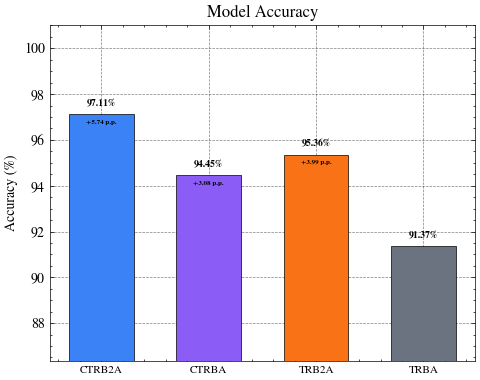

In [2]:
# ── Gráfico 1: Model Accuracy ────────────────────────────────────────────────

models = ordered_models(data["models"])

with plt.style.context(["science", "no-latex", "grid"]):
    fig, ax = plt.subplots(figsize=(5, 4))

    labels = [m["label"] for m in models]
    accuracies = [m["plate_accuracy"] * 100 for m in models]
    colors = [MODEL_COLORS.get(lbl, "#999") for lbl in labels]

    trba_acc = next((m["plate_accuracy"] * 100 for m in models if m["label"] == "TRBA"), None)

    x = np.arange(len(labels))
    bars = ax.bar(x, accuracies, color=colors, edgecolor="black", linewidth=0.5, width=0.6)

    for bar, lbl, acc in zip(bars, labels, accuracies):
        ref = None if lbl == "TRBA" else trba_acc
        _annotate_bar(ax, bar, acc, ref, higher_is_better=True)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Model Accuracy")

    y_min = max(0, min(accuracies) - 5)
    ax.set_ylim(y_min, 101)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

    fig.tight_layout()
    plt.show()

## 2. Errors per Character Class

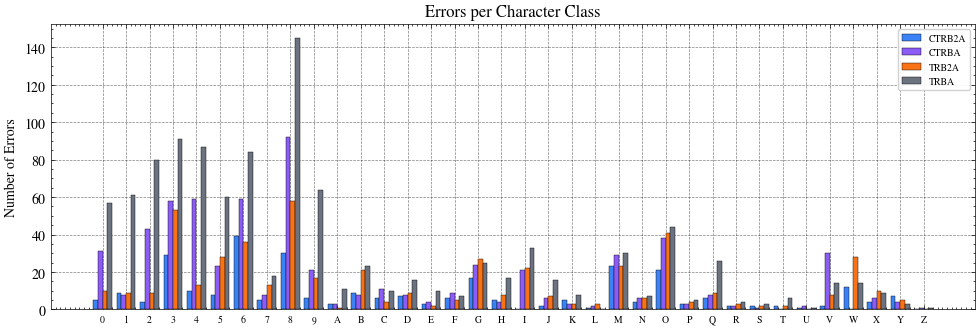

In [3]:
# ── Gráfico 2: Errors per Class ──────────────────────────────────────────────

models = ordered_models(data["models"])

all_classes = sorted(
    set(cls for m in models for cls in m.get("class_errors", {}).keys())
)

if all_classes:
    with plt.style.context(["science", "no-latex", "grid"]):
        fig, ax = plt.subplots(figsize=(10, 3.5))

        n_classes = len(all_classes)
        n_models = len(models)
        bar_width = 0.8 / n_models
        x = np.arange(n_classes)

        for i, m in enumerate(models):
            lbl = m["label"]
            errors = [m.get("class_errors", {}).get(cls, 0) for cls in all_classes]
            offset = (i - (n_models - 1) / 2) * bar_width
            ax.bar(
                x + offset,
                errors,
                width=bar_width,
                label=lbl,
                color=MODEL_COLORS.get(lbl, "#999"),
                edgecolor="black",
                linewidth=0.3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(all_classes, fontsize=7)
        ax.set_ylabel("Number of Errors")
        ax.set_title("Errors per Character Class")
        ax.legend(fontsize=7, loc="upper right", framealpha=0.9)

        fig.tight_layout()
        plt.show()
else:
    print("Sem dados de class_errors disponíveis.")

## 3. Accuracy per Vehicle Type

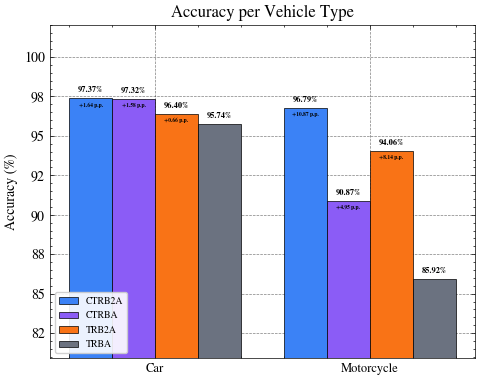

In [4]:
# ── Gráfico 3: Accuracy per Vehicle Type ─────────────────────────────────────

models = ordered_models(data["models"])
models_vt = [m for m in models if m.get("vehicle_type_metrics")]

if models_vt:
    vehicle_types = ["car", "motorcycle"]
    vehicle_labels = ["Car", "Motorcycle"]

    trba_model = next((m for m in models_vt if m["label"] == "TRBA"), None)
    trba_accs_vt = {
        vt: (trba_model["vehicle_type_metrics"].get(vt, {}).get("accuracy", 0) * 100
             if trba_model else None)
        for vt in vehicle_types
    }

    with plt.style.context(["science", "no-latex", "grid"]):
        fig, ax = plt.subplots(figsize=(5, 4))

        n_vehicles = len(vehicle_types)
        n_models = len(models_vt)
        bar_width = 0.8 / n_models
        x = np.arange(n_vehicles)

        for i, m in enumerate(models_vt):
            lbl = m["label"]
            accs = [
                m["vehicle_type_metrics"].get(vt, {}).get("accuracy", 0) * 100
                for vt in vehicle_types
            ]

            offset = (i - (n_models - 1) / 2) * bar_width
            bars = ax.bar(
                x + offset, accs,
                width=bar_width, label=lbl,
                color=MODEL_COLORS.get(lbl, "#999"),
                edgecolor="black", linewidth=0.5,
            )

            for bar, vt, acc in zip(bars, vehicle_types, accs):
                ref = None if lbl == "TRBA" else trba_accs_vt.get(vt)
                _annotate_bar(ax, bar, acc, ref, higher_is_better=True,
                              fontsize_value=6, fontsize_delta=4)

        ax.set_xticks(x)
        ax.set_xticklabels(vehicle_labels, fontsize=9)
        ax.set_ylabel("Accuracy (%)")
        ax.set_title("Accuracy per Vehicle Type")
        ax.legend(fontsize=7, loc="lower left", framealpha=0.9)

        y_min = max(0, min(
            m["vehicle_type_metrics"].get(vt, {}).get("accuracy", 0) * 100
            for m in models_vt for vt in vehicle_types
        ) - 5)
        ax.set_ylim(y_min, 102)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

        fig.tight_layout()
        plt.show()
else:
    print("Sem dados de vehicle_type_metrics disponíveis.")

## 4. Character Error Rate (CER)

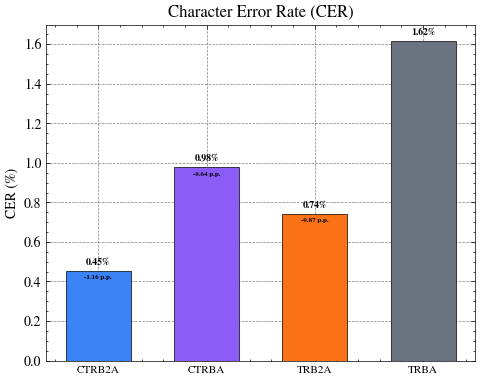

In [5]:
# ── Gráfico 4: CER (Character Error Rate) ────────────────────────────────────

models = ordered_models(data["models"])

with plt.style.context(["science", "no-latex", "grid"]):
    fig, ax = plt.subplots(figsize=(5, 4))

    labels = [m["label"] for m in models]
    cers = [m["cer"] * 100 for m in models]
    colors = [MODEL_COLORS.get(lbl, "#999") for lbl in labels]

    trba_cer = next((m["cer"] * 100 for m in models if m["label"] == "TRBA"), None)

    x = np.arange(len(labels))
    bars = ax.bar(x, cers, color=colors, edgecolor="black", linewidth=0.5, width=0.6)

    for bar, lbl, cer in zip(bars, labels, cers):
        ref = None if lbl == "TRBA" else trba_cer
        _annotate_bar(ax, bar, cer, ref, higher_is_better=False)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("CER (%)")
    ax.set_title("Character Error Rate (CER)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

    fig.tight_layout()
    plt.show()

## 5. CER per Vehicle Type

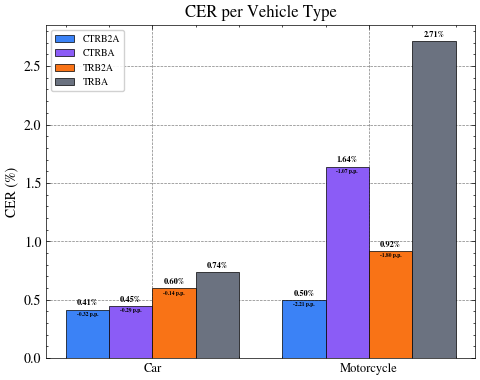

In [6]:
# ── Gráfico 5: CER per Vehicle Type ──────────────────────────────────────────

models = ordered_models(data["models"])
models_vt = [m for m in models if m.get("vehicle_type_metrics")]

if models_vt:
    vehicle_types = ["car", "motorcycle"]
    vehicle_labels = ["Car", "Motorcycle"]

    trba_model = next((m for m in models_vt if m["label"] == "TRBA"), None)
    trba_cers_vt = {
        vt: (trba_model["vehicle_type_metrics"].get(vt, {}).get("cer", 0) * 100
             if trba_model else None)
        for vt in vehicle_types
    }

    with plt.style.context(["science", "no-latex", "grid"]):
        fig, ax = plt.subplots(figsize=(5, 4))

        n_vehicles = len(vehicle_types)
        n_models = len(models_vt)
        bar_width = 0.8 / n_models
        x = np.arange(n_vehicles)

        for i, m in enumerate(models_vt):
            lbl = m["label"]
            cers = [
                m["vehicle_type_metrics"].get(vt, {}).get("cer", 0) * 100
                for vt in vehicle_types
            ]

            offset = (i - (n_models - 1) / 2) * bar_width
            bars = ax.bar(
                x + offset, cers,
                width=bar_width, label=lbl,
                color=MODEL_COLORS.get(lbl, "#999"),
                edgecolor="black", linewidth=0.5,
            )

            for bar, vt, cer in zip(bars, vehicle_types, cers):
                ref = None if lbl == "TRBA" else trba_cers_vt.get(vt)
                _annotate_bar(ax, bar, cer, ref, higher_is_better=False,
                              fontsize_value=6, fontsize_delta=4)

        ax.set_xticks(x)
        ax.set_xticklabels(vehicle_labels, fontsize=9)
        ax.set_ylabel("CER (%)")
        ax.set_title("CER per Vehicle Type")
        ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

        fig.tight_layout()
        plt.show()
else:
    print("Sem dados de vehicle_type_metrics disponíveis.")

## 6. Class Error Rate (per class)

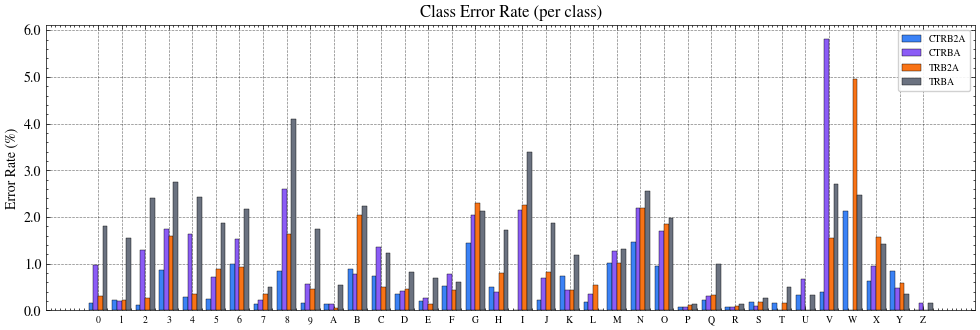

In [7]:
# ── Gráfico 6: Class Error Rate (by class) ───────────────────────────────────

models = ordered_models(data["models"])
models_cer_class = [m for m in models if m.get("class_error_rate_class")]

if models_cer_class:
    all_classes = sorted(
        set(cls for m in models_cer_class for cls in m.get("class_error_rate_class", {}).keys())
    )

    if all_classes:
        with plt.style.context(["science", "no-latex", "grid"]):
            fig, ax = plt.subplots(figsize=(10, 3.5))

            n_classes = len(all_classes)
            n_models = len(models_cer_class)
            bar_width = 0.8 / n_models
            x = np.arange(n_classes)

            for i, m in enumerate(models_cer_class):
                lbl = m["label"]
                rates = [
                    m.get("class_error_rate_class", {}).get(cls, 0) * 100
                    for cls in all_classes
                ]
                offset = (i - (n_models - 1) / 2) * bar_width
                ax.bar(
                    x + offset,
                    rates,
                    width=bar_width,
                    label=lbl,
                    color=MODEL_COLORS.get(lbl, "#999"),
                    edgecolor="black",
                    linewidth=0.3,
                )

            ax.set_xticks(x)
            ax.set_xticklabels(all_classes, fontsize=7)
            ax.set_ylabel("Error Rate (%)")
            ax.set_title("Class Error Rate (per class)")
            ax.legend(fontsize=7, loc="upper right", framealpha=0.9)
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

            fig.tight_layout()
            plt.show()
    else:
        print("Sem classes encontradas.")
else:
    print("Sem dados de class_error_rate_class disponíveis.")

## 7. RodoSol / UFPR Split Accuracy

Este gráfico depende dos arquivos CSV de predições no diretório `results/rodo_ufpr/`.
Se os CSVs não estiverem disponíveis, a célula será ignorada.

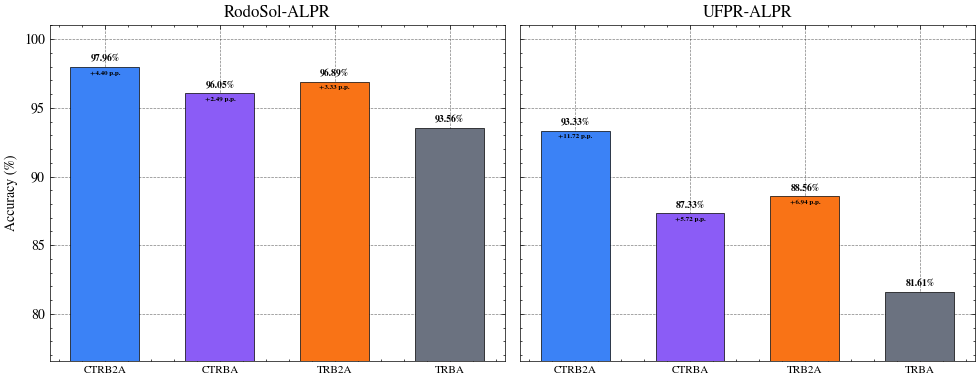

In [8]:
# ── Gráfico 7: Rodo/UFPR Split Accuracy ──────────────────────────────────────

import csv

if DATASET_NAME == "rodo_ufpr":
    models = ordered_models(data.get("models", []))
    results_dir = METRICS_JSON.parent

    labels = [m["label"] for m in models]
    colors = [MODEL_COLORS.get(lbl, "#999") for lbl in labels]

    rodosol_accs = []
    ufpr_accs = []
    csv_found = True

    for m in models:
        run_id = m["run_id"]
        csv_files = list(results_dir.glob(f"predictions_*{run_id[:8]}*.csv"))
        if not csv_files:
            print(f"  [WARN] CSV não encontrado para {m['label']} ({run_id}). Pulando gráfico.")
            csv_found = False
            break

        csv_path = csv_files[0]
        rodo_correct = rodo_total = ufpr_correct = ufpr_total = 0

        with open(csv_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                img = row["img"]
                correct = row["correct"] == "True"
                if img.startswith("img_"):
                    rodo_total += 1
                    if correct:
                        rodo_correct += 1
                else:
                    ufpr_total += 1
                    if correct:
                        ufpr_correct += 1

        rodosol_accs.append((rodo_correct / rodo_total * 100) if rodo_total > 0 else 0)
        ufpr_accs.append((ufpr_correct / ufpr_total * 100) if ufpr_total > 0 else 0)

    if csv_found and models:
        with plt.style.context(["science", "no-latex", "grid"]):
            fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
            x = np.arange(len(labels))

            # Subplot 1: rodosol-alpr
            ax1 = axes[0]
            bars1 = ax1.bar(x, rodosol_accs, color=colors, edgecolor="black", linewidth=0.5, width=0.6)
            trba_acc_rodo = next((acc for lbl, acc in zip(labels, rodosol_accs) if lbl == "TRBA"), None)
            for bar, lbl, acc in zip(bars1, labels, rodosol_accs):
                ref = None if lbl == "TRBA" else trba_acc_rodo
                _annotate_bar(ax1, bar, acc, ref, higher_is_better=True)
            ax1.set_xticks(x)
            ax1.set_xticklabels(labels, fontsize=8)
            ax1.set_title("RodoSol-ALPR", fontsize=12)
            ax1.set_ylabel("Accuracy (%)")

            # Subplot 2: ufpr-alpr
            ax2 = axes[1]
            bars2 = ax2.bar(x, ufpr_accs, color=colors, edgecolor="black", linewidth=0.5, width=0.6)
            trba_acc_ufpr = next((acc for lbl, acc in zip(labels, ufpr_accs) if lbl == "TRBA"), None)
            for bar, lbl, acc in zip(bars2, labels, ufpr_accs):
                ref = None if lbl == "TRBA" else trba_acc_ufpr
                _annotate_bar(ax2, bar, acc, ref, higher_is_better=True)
            ax2.set_xticks(x)
            ax2.set_xticklabels(labels, fontsize=8)
            ax2.set_title("UFPR-ALPR", fontsize=12)

            all_accs = rodosol_accs + ufpr_accs
            if all_accs:
                y_min = max(0, min(all_accs) - 5)
                axes[0].set_ylim(y_min, 101)
                axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))

            fig.tight_layout()
            plt.show()
else:
    print(f"Gráfico de split accuracy disponível apenas para dataset 'rodo_ufpr' (atual: '{DATASET_NAME}').")